In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "figures" / "part3"
OUT_DIR = BASE_DIR / "outputs" / "part3"

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
input_path = PROCESSED_DIR / "audusd_part1_corrected.csv"

df = pd.read_csv(input_path, parse_dates=["Date"])

needed_cols = [
    "Date",
    "spot",
    "fx_return",
    "rate_au",
    "rate_us"
]

df = df[needed_cols].copy()
df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)
df.head()

(179, 5)


,Date,spot,fx_return,rate_au,rate_us
0,2009-02-28,0.642219,0.005827,3.35,0.16
1,2009-03-31,0.691802,0.074370,3.25,0.17
2,2009-04-30,0.726691,0.049202,3.06,0.04
3,2009-05-31,0.801025,0.097391,3.00,0.14
4,2009-06-30,0.806192,0.006429,3.00,0.17


In [3]:
strategy = df.copy()

# Previous-month interest rates, annual percentage form
strategy["rate_au_lag"] = strategy["rate_au"].shift(1)
strategy["rate_us_lag"] = strategy["rate_us"].shift(1)

# Convert annual percentage rates into monthly decimal rates
strategy["i_au_m"] = strategy["rate_au_lag"] / 100 / 12
strategy["i_us_m"] = strategy["rate_us_lag"] / 100 / 12

# Interest differential used for the carry signal
# Positive = Australia has higher interest rate than the US
strategy["rate_diff_lag"] = strategy["rate_au_lag"] - strategy["rate_us_lag"]

# Carry signal:
# +1 = long AUD / short USD
# -1 = long USD / short AUD
strategy["signal"] = np.where(strategy["rate_diff_lag"] > 0, 1, -1)

strategy["position"] = np.where(
    strategy["signal"] == 1,
    "Long AUD / Short USD",
    "Long USD / Short AUD"
)

# Drop rows where lagged interest rates are unavailable
strategy = strategy.dropna(subset=["rate_au_lag", "rate_us_lag", "fx_return"]).copy()
strategy.reset_index(drop=True, inplace=True)

strategy[
    [
        "Date",
        "spot",
        "fx_return",
        "rate_au_lag",
        "rate_us_lag",
        "rate_diff_lag",
        "position"
    ]
].head(12)

,Date,spot,fx_return,rate_au_lag,rate_us_lag,rate_diff_lag,position
0,2009-03-31,0.691802,0.074370,3.35,0.16,3.19,Long AUD / Short USD
1,2009-04-30,0.726691,0.049202,3.25,0.17,3.08,Long AUD / Short USD
2,2009-05-31,0.801025,0.097391,3.06,0.04,3.02,Long AUD / Short USD
3,2009-06-30,0.806192,0.006429,3.00,0.14,2.86,Long AUD / Short USD
4,2009-07-31,0.835631,0.035866,3.00,0.17,2.83,Long AUD / Short USD
5,2009-08-31,0.842886,0.008644,3.00,0.14,2.86,Long AUD / Short USD
6,2009-09-30,0.883783,0.047379,3.00,0.11,2.89,Long AUD / Short USD
7,2009-10-31,0.900982,0.019274,3.00,0.06,2.94,Long AUD / Short USD
8,2009-11-30,0.917600,0.018276,3.21,0.01,3.20,Long AUD / Short USD
9,2009-12-31,0.898311,-0.021245,3.48,0.08,3.40,Long AUD / Short USD


In [4]:
# Log carry differential from investing in AUD versus USD
strategy["carry_log_diff"] = np.log1p(strategy["i_au_m"]) - np.log1p(strategy["i_us_m"])

# FX component in log terms
# If signal = +1, we benefit from an increase in S(USD/AUD)
# If signal = -1, we benefit from a decrease in S(USD/AUD)
strategy["fx_log_component"] = strategy["signal"] * strategy["fx_return"]

# Carry component in log terms
strategy["carry_log_component"] = strategy["signal"] * strategy["carry_log_diff"]

# Total log return
strategy["strategy_log_return"] = (
    strategy["fx_log_component"] + strategy["carry_log_component"]
)

# Convert log return into simple monthly return
strategy["strategy_return"] = np.exp(strategy["strategy_log_return"]) - 1

strategy["year"] = strategy["Date"].dt.year

strategy[
    [
        "Date",
        "position",
        "fx_log_component",
        "carry_log_component",
        "strategy_log_return",
        "strategy_return"
    ]
].head(12)

,Date,position,fx_log_component,carry_log_component,strategy_log_return,strategy_return
0,2009-03-31,Long AUD / Short USD,0.074370,0.002654,0.077024,0.080068
1,2009-04-30,Long AUD / Short USD,0.049202,0.002563,0.051765,0.053128
2,2009-05-31,Long AUD / Short USD,0.097391,0.002513,0.099904,0.105065
3,2009-06-30,Long AUD / Short USD,0.006429,0.002380,0.008809,0.008848
4,2009-07-31,Long AUD / Short USD,0.035866,0.002355,0.038221,0.038961
5,2009-08-31,Long AUD / Short USD,0.008644,0.002380,0.011024,0.011085
6,2009-09-30,Long AUD / Short USD,0.047379,0.002405,0.049785,0.051045
7,2009-10-31,Long AUD / Short USD,0.019274,0.002447,0.021721,0.021959
8,2009-11-30,Long AUD / Short USD,0.018276,0.002663,0.020939,0.021160
9,2009-12-31,Long AUD / Short USD,-0.021245,0.002829,-0.018415,-0.018247


In [5]:
insample = strategy[
    (strategy["Date"] >= "2009-01-01") &
    (strategy["Date"] <= "2019-12-31")
].copy()

oos = strategy[
    (strategy["Date"] >= "2020-01-01") &
    (strategy["Date"] <= "2023-12-31")
].copy()

print("In-sample:", insample["Date"].min(), "to", insample["Date"].max(), insample.shape)
print("Out-of-sample:", oos["Date"].min(), "to", oos["Date"].max(), oos.shape)

In-sample: 2009-03-31 00:00:00 to 2019-12-31 00:00:00 (130, 18)
Out-of-sample: 2020-01-31 00:00:00 to 2023-12-31 00:00:00 (48, 18)


In [6]:
def add_wealth_index(data, start_value=100):
    out = data.copy()
    out["wealth_index"] = start_value * (1 + out["strategy_return"]).cumprod()
    return out

insample = add_wealth_index(insample, start_value=100)
oos = add_wealth_index(oos, start_value=100)

insample[["Date", "strategy_return", "wealth_index"]].head()

,Date,strategy_return,wealth_index
0,2009-03-31,0.080068,108.006835
1,2009-04-30,0.053128,113.745042
2,2009-05-31,0.105065,125.695652
3,2009-06-30,0.008848,126.807801
4,2009-07-31,0.038961,131.748381


In [22]:
def max_drawdown(wealth):
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min()

def performance_summary(data, sample_name):
    total_return = data["wealth_index"].iloc[-1] / 100 - 1
    n_months = len(data)
    annualised_return = (1 + total_return) ** (12 / n_months) - 1
    monthly_vol = data["strategy_return"].std()
    annualised_vol = monthly_vol * np.sqrt(12)
    sharpe = annualised_return / annualised_vol if annualised_vol != 0 else np.nan

    return {
        "Sample": sample_name,
        "Start date": data["Date"].min().strftime("%Y-%m"),
        "End date": data["Date"].max().strftime("%Y-%m"),
        "N months": n_months,
        "Total return": total_return,
        "Annualised return": annualised_return,
        "Annualised volatility": annualised_vol,
        "Sharpe ratio": sharpe,
        "Maximum drawdown": max_drawdown(data["wealth_index"]),
        "Hit rate": (data["strategy_return"] > 0).mean()
    }

table4_performance_summary = pd.DataFrame([
    performance_summary(insample, "In-sample"),
    performance_summary(oos, "Out-of-sample")
])

percent_cols = [
    "Total return",
    "Annualised return",
    "Annualised volatility",
    "Maximum drawdown",
    "Hit rate"
]

table4_display = table4_performance_summary.copy()

for col in percent_cols:
    table4_display[col] = (table4_display[col] * 100).round(1).astype(str) + "%"

table4_display["Sharpe ratio"] = table4_display["Sharpe ratio"].round(2)

display(Markdown("**Table 4. Carry Trade Performance Summary**"))
display(table4_display)

**Table 4. Carry Trade Performance Summary**

,Sample,Start date,End date,N months,Total return,Annualised return,Annualised volatility,Sharpe ratio,Maximum drawdown,Hit rate
0,In-sample,2009-03,2019-12,130,75.0%,5.3%,11.9%,0.45,-28.5%,56.9%
1,Out-of-sample,2020-01,2023-12,48,50.6%,10.8%,11.1%,0.97,-13.6%,56.2%


In [23]:
table3_strategy_design = pd.DataFrame({
    "Item": [
        "Exchange rate convention",
        "Strategy signal",
        "Long AUD / short USD condition",
        "Long USD / short AUD condition",
        "Timing",
        "Rebalancing frequency",
        "Return calculation"
    ],
    "Implementation rule": [
        "S(USD/AUD), the U.S. dollar price of one Australian dollar.",
        "Previous-month short-term interest rate differential.",
        "Used when the previous-month Australian rate is above the U.S. rate.",
        "Used when the previous-month U.S. rate is above the Australian rate.",
        "Positions use lagged interest rates to avoid look-ahead bias.",
        "Monthly.",
        "Monthly return combines the carry component and the realised change in S(USD/AUD)."
    ]
})

display(Markdown("**Table 3. Carry Trade Strategy Design and Implementation Rules**"))
display(table3_strategy_design)

**Table 3. Carry Trade Strategy Design and Implementation Rules**

,Item,Implementation rule
0,Exchange rate convention,"S(USD/AUD), the U.S. dollar price of one Austr..."
1,Strategy signal,Previous-month short-term interest rate differ...
2,Long AUD / short USD condition,Used when the previous-month Australian rate i...
3,Long USD / short AUD condition,Used when the previous-month U.S. rate is abov...
4,Timing,Positions use lagged interest rates to avoid l...
5,Rebalancing frequency,Monthly.
6,Return calculation,Monthly return combines the carry component an...


In [24]:
appendix_table_D3_return_decomposition = pd.DataFrame({
    "Sample": ["In-sample", "Out-of-sample"],
    "Mean monthly strategy log return": [
        insample["strategy_log_return"].mean(),
        oos["strategy_log_return"].mean()
    ],
    "Mean monthly carry component": [
        insample["carry_log_component"].mean(),
        oos["carry_log_component"].mean()
    ],
    "Mean monthly FX component": [
        insample["fx_log_component"].mean(),
        oos["fx_log_component"].mean()
    ]
})

appendix_table_D3_display = appendix_table_D3_return_decomposition.copy()

for col in [
    "Mean monthly strategy log return",
    "Mean monthly carry component",
    "Mean monthly FX component"
]:
    appendix_table_D3_display[col] = (appendix_table_D3_display[col] * 100).round(2).astype(str) + "%"

display(Markdown("**Appendix Table D3. Return Decomposition**"))
display(appendix_table_D3_display)

**Appendix Table D3. Return Decomposition**

,Sample,Mean monthly strategy log return,Mean monthly carry component,Mean monthly FX component
0,In-sample,0.43%,0.2%,0.23%
1,Out-of-sample,0.85%,0.04%,0.81%


In [25]:
yearly_returns = (
    strategy
    .groupby(["year"])
    .apply(lambda x: (1 + x["strategy_return"]).prod() - 1)
    .reset_index(name="yearly_return")
)

yearly_returns["sample"] = np.where(
    yearly_returns["year"] <= 2019,
    "In-sample",
    "Out-of-sample"
)

display(yearly_returns)

,year,yearly_return,sample
0,2009,0.434444,In-sample
1,2010,0.178408,In-sample
2,2011,0.045996,In-sample
3,2012,0.063750,In-sample
4,2013,-0.117783,In-sample
5,2014,-0.059527,In-sample
6,2015,-0.090741,In-sample
7,2016,0.008677,In-sample
8,2017,0.084978,In-sample
9,2018,0.110009,In-sample


In [26]:
strategy["rolling_12m_return"] = (
    (1 + strategy["strategy_return"])
    .rolling(12)
    .apply(np.prod, raw=True)
    - 1
)

strategy["rolling_12m_start"] = strategy["Date"].shift(11)

insample_roll = strategy[
    (strategy["Date"] >= "2009-01-01") &
    (strategy["Date"] <= "2019-12-31")
].dropna(subset=["rolling_12m_return"]).copy()

oos_roll = strategy[
    (strategy["Date"] >= "2020-01-01") &
    (strategy["Date"] <= "2023-12-31")
].dropna(subset=["rolling_12m_return"]).copy()

appendix_table_D1_key_subperiods = pd.DataFrame([
    {
        "Period": "Best in-sample 12-month period",
        "Start date": insample_roll.loc[insample_roll["rolling_12m_return"].idxmax(), "rolling_12m_start"],
        "End date": insample_roll.loc[insample_roll["rolling_12m_return"].idxmax(), "Date"],
        "Return": insample_roll["rolling_12m_return"].max()
    },
    {
        "Period": "Worst in-sample 12-month period",
        "Start date": insample_roll.loc[insample_roll["rolling_12m_return"].idxmin(), "rolling_12m_start"],
        "End date": insample_roll.loc[insample_roll["rolling_12m_return"].idxmin(), "Date"],
        "Return": insample_roll["rolling_12m_return"].min()
    },
    {
        "Period": "Best out-of-sample 12-month period",
        "Start date": oos_roll.loc[oos_roll["rolling_12m_return"].idxmax(), "rolling_12m_start"],
        "End date": oos_roll.loc[oos_roll["rolling_12m_return"].idxmax(), "Date"],
        "Return": oos_roll["rolling_12m_return"].max()
    },
    {
        "Period": "Worst out-of-sample 12-month period",
        "Start date": oos_roll.loc[oos_roll["rolling_12m_return"].idxmin(), "rolling_12m_start"],
        "End date": oos_roll.loc[oos_roll["rolling_12m_return"].idxmin(), "Date"],
        "Return": oos_roll["rolling_12m_return"].min()
    }
])

appendix_table_D1_display = appendix_table_D1_key_subperiods.copy()
appendix_table_D1_display["Start date"] = appendix_table_D1_display["Start date"].dt.strftime("%Y-%m")
appendix_table_D1_display["End date"] = appendix_table_D1_display["End date"].dt.strftime("%Y-%m")
appendix_table_D1_display["Return"] = (appendix_table_D1_display["Return"] * 100).round(1).astype(str) + "%"

display(Markdown("**Appendix Table D1. Key 12-Month Carry Trade Sub-Periods**"))
display(appendix_table_D1_display)

**Appendix Table D1. Key 12-Month Carry Trade Sub-Periods**

,Period,Start date,End date,Return
0,Best in-sample 12-month period,2009-03,2010-02,43.9%
1,Worst in-sample 12-month period,2014-09,2015-08,-21.9%
2,Best out-of-sample 12-month period,2020-01,2020-12,41.9%
3,Worst out-of-sample 12-month period,2021-02,2022-01,-11.3%


In [27]:
initial_notional = 1000

def checkpoint(data, date_label, checkpoint_date):
    subset = data[data["Date"] <= checkpoint_date].copy()
    wealth = subset["wealth_index"].iloc[-1]
    portfolio_value = initial_notional * wealth / 100
    profit_loss = portfolio_value - initial_notional
    
    return {
        "Checkpoint": date_label,
        "Date": subset["Date"].iloc[-1],
        "Wealth index": wealth,
        "Portfolio value": portfolio_value,
        "Profit / loss": profit_loss,
        "Cumulative return": wealth / 100 - 1
    }

appendix_table_D2_pnl_checkpoints = pd.DataFrame([
    checkpoint(oos, "End-2021", "2021-12-31"),
    checkpoint(oos, "End-2023", "2023-12-31")
])

appendix_table_D2_display = appendix_table_D2_pnl_checkpoints.copy()
appendix_table_D2_display["Date"] = appendix_table_D2_display["Date"].dt.strftime("%Y-%m")
appendix_table_D2_display["Wealth index"] = appendix_table_D2_display["Wealth index"].round(1)
appendix_table_D2_display["Portfolio value"] = appendix_table_D2_display["Portfolio value"].round(2)
appendix_table_D2_display["Profit / loss"] = appendix_table_D2_display["Profit / loss"].round(2)
appendix_table_D2_display["Cumulative return"] = (appendix_table_D2_display["Cumulative return"] * 100).round(1).astype(str) + "%"

display(Markdown("**Appendix Table D2. Out-of-Sample Notional P/L Checkpoints**"))
display(appendix_table_D2_display)

**Appendix Table D2. Out-of-Sample Notional P/L Checkpoints**

,Checkpoint,Date,Wealth index,Portfolio value,Profit / loss,Cumulative return
0,End-2021,2021-12,130.0,1300.47,300.47,30.0%
1,End-2023,2023-12,150.6,1505.81,505.81,50.6%


In [13]:
position_data = strategy[["Date", "position"]].copy()
position_data["position_change"] = position_data["position"] != position_data["position"].shift(1)
position_data["spell_id"] = position_data["position_change"].cumsum()

position_spells = (
    position_data
    .groupby("spell_id")
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        position=("position", "first"),
        n_months=("Date", "count")
    )
    .reset_index(drop=True)
)

position_spells

,start_date,end_date,position,n_months
0,2009-03-31,2018-02-28,Long AUD / Short USD,108
1,2018-03-31,2020-03-31,Long USD / Short AUD,25
2,2020-04-30,2021-11-30,Long AUD / Short USD,20
3,2021-12-31,2021-12-31,Long USD / Short AUD,1
4,2022-01-31,2022-03-31,Long AUD / Short USD,3
5,2022-04-30,2023-12-31,Long USD / Short AUD,21


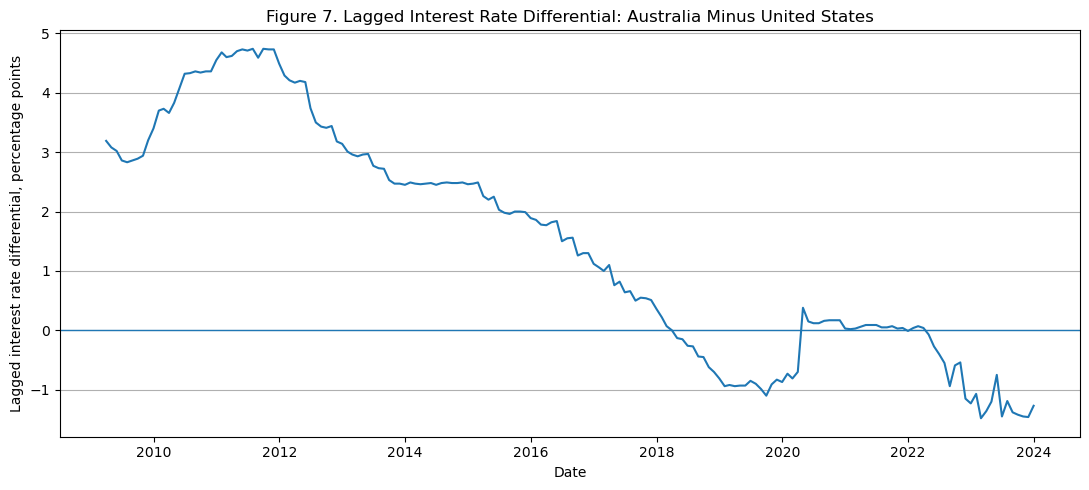

In [28]:
plt.figure(figsize=(11, 5))
plt.plot(strategy["Date"], strategy["rate_diff_lag"])
plt.axhline(0, linewidth=1)
plt.title("Figure 7. Lagged Interest Rate Differential: Australia Minus United States")
plt.xlabel("Date")
plt.ylabel("Lagged interest rate differential, percentage points")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure7_lagged_interest_rate_differential.png", dpi=300, bbox_inches="tight")
plt.show()

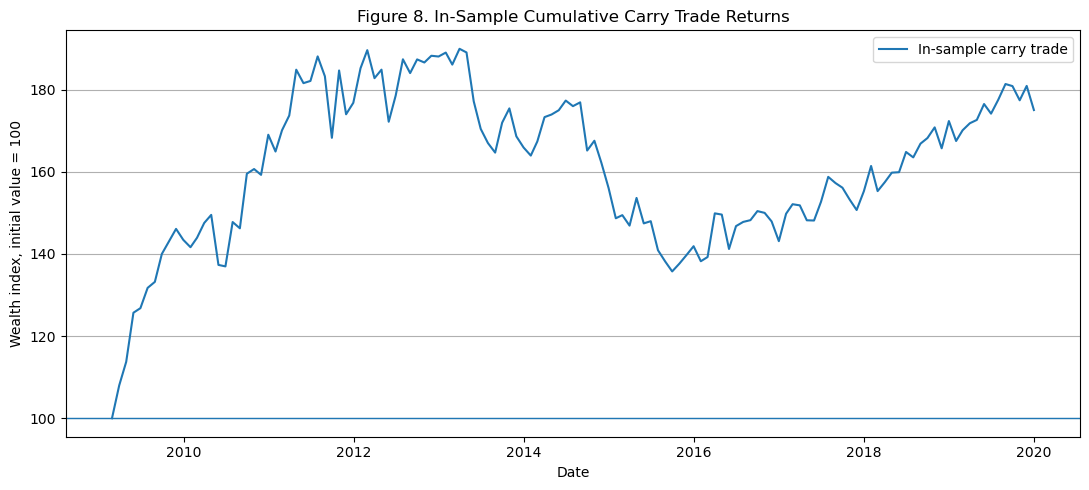

In [29]:
plt.figure(figsize=(11, 5))

start_date = insample["Date"].iloc[0] - pd.offsets.MonthEnd(1)
plot_dates = pd.concat([
    pd.Series([start_date]),
    insample["Date"]
])

plot_values = pd.concat([
    pd.Series([100]),
    insample["wealth_index"]
])

plt.plot(plot_dates, plot_values, label="In-sample carry trade")
plt.axhline(100, linewidth=1)
plt.title("Figure 8. In-Sample Cumulative Carry Trade Returns")
plt.xlabel("Date")
plt.ylabel("Wealth index, initial value = 100")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure8_insample_cumulative_carry_trade_returns.png", dpi=300, bbox_inches="tight")
plt.show()

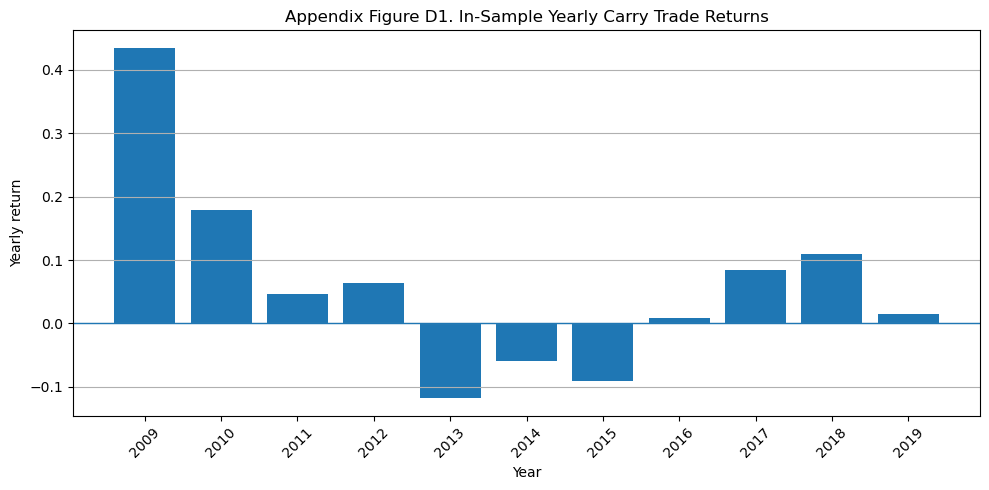

In [30]:
insample_yearly = yearly_returns[yearly_returns["sample"] == "In-sample"]

plt.figure(figsize=(10, 5))
plt.bar(insample_yearly["year"].astype(str), insample_yearly["yearly_return"])
plt.axhline(0, linewidth=1)
plt.title("Appendix Figure D1. In-Sample Yearly Carry Trade Returns")
plt.xlabel("Year")
plt.ylabel("Yearly return")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "appendix_figure_D1_insample_yearly_carry_trade_returns.png", dpi=300, bbox_inches="tight")
plt.show()

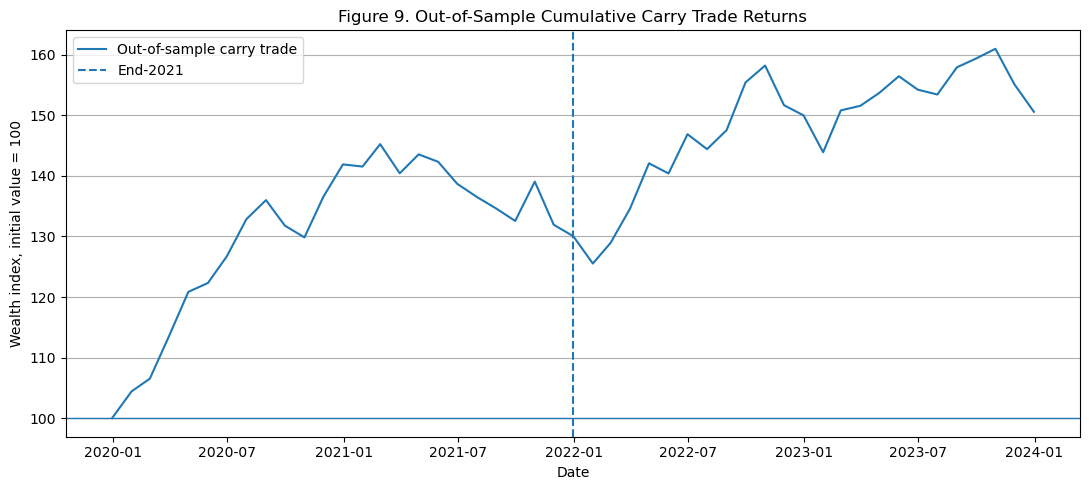

In [31]:
plt.figure(figsize=(11, 5))

start_date = oos["Date"].iloc[0] - pd.offsets.MonthEnd(1)
plot_dates = pd.concat([
    pd.Series([start_date]),
    oos["Date"]
])

plot_values = pd.concat([
    pd.Series([100]),
    oos["wealth_index"]
])

plt.plot(plot_dates, plot_values, label="Out-of-sample carry trade")
plt.axhline(100, linewidth=1)
plt.axvline(pd.Timestamp("2021-12-31"), linestyle="--", label="End-2021")
plt.title("Figure 9. Out-of-Sample Cumulative Carry Trade Returns")
plt.xlabel("Date")
plt.ylabel("Wealth index, initial value = 100")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure9_oos_cumulative_carry_trade_returns.png", dpi=300, bbox_inches="tight")
plt.show()

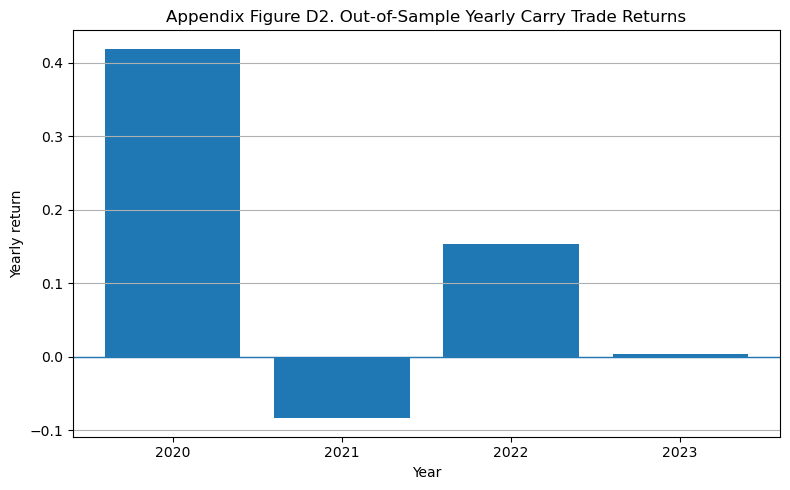

In [32]:
oos_yearly = yearly_returns[yearly_returns["sample"] == "Out-of-sample"]

plt.figure(figsize=(8, 5))
plt.bar(oos_yearly["year"].astype(str), oos_yearly["yearly_return"])
plt.axhline(0, linewidth=1)
plt.title("Appendix Figure D2. Out-of-Sample Yearly Carry Trade Returns")
plt.xlabel("Year")
plt.ylabel("Yearly return")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "appendix_figure_D2_oos_yearly_carry_trade_returns.png", dpi=300, bbox_inches="tight")
plt.show()

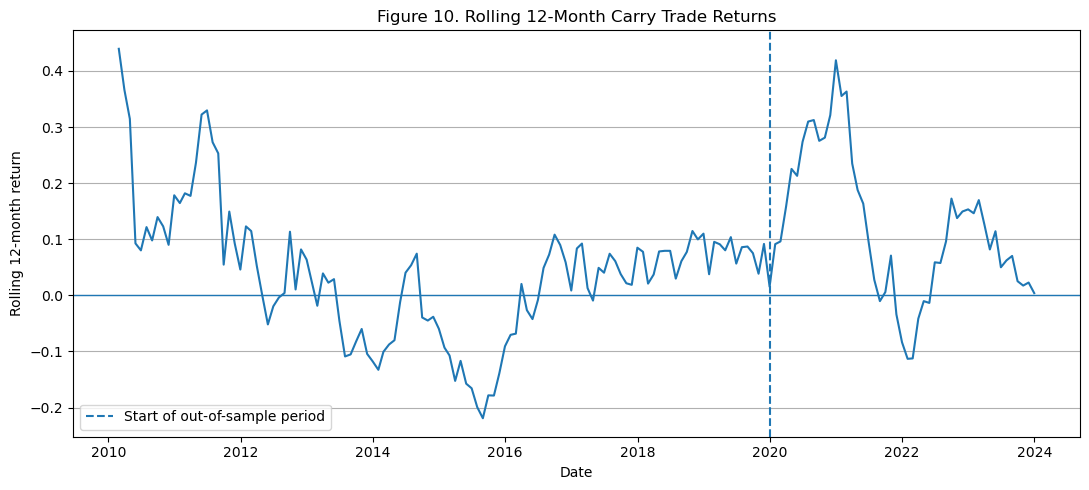

In [33]:
plt.figure(figsize=(11, 5))
plt.plot(strategy["Date"], strategy["rolling_12m_return"])
plt.axhline(0, linewidth=1)
plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--", label="Start of out-of-sample period")
plt.title("Figure 10. Rolling 12-Month Carry Trade Returns")
plt.xlabel("Date")
plt.ylabel("Rolling 12-month return")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure10_rolling_12m_carry_trade_returns.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
strategy.to_csv(OUT_DIR / "part3_strategy_data.csv", index=False)

table3_strategy_design.to_csv(
    OUT_DIR / "table3_carry_trade_strategy_design_implementation_rules.csv",
    index=False
)

table4_performance_summary.to_csv(
    OUT_DIR / "table4_carry_trade_performance_summary.csv",
    index=False
)

appendix_table_D1_key_subperiods.to_csv(
    OUT_DIR / "appendix_table_D1_key_12_month_carry_trade_subperiods.csv",
    index=False
)

appendix_table_D2_pnl_checkpoints.to_csv(
    OUT_DIR / "appendix_table_D2_oos_notional_pnl_checkpoints.csv",
    index=False
)

appendix_table_D3_return_decomposition.to_csv(
    OUT_DIR / "appendix_table_D3_return_decomposition.csv",
    index=False
)

yearly_returns.to_csv(
    OUT_DIR / "supporting_yearly_returns.csv",
    index=False
)

position_spells.to_csv(
    OUT_DIR / "supporting_position_spells.csv",
    index=False
)

print("Part III notebook completed successfully.")
print("Figures saved to:", FIG_DIR)
print("Tables and outputs saved to:", OUT_DIR)

Part III notebook completed successfully.
Figures saved to: /Users/marwanferreira/Desktop/audusd-carry-uip-ppp/figures/part3
Tables and outputs saved to: /Users/marwanferreira/Desktop/audusd-carry-uip-ppp/outputs/part3
